In [2]:
import GEOparse
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

print("✅ Libraries are ready")


✅ Libraries are ready


In [3]:
data_obj = load_breast_cancer()
data = pd.DataFrame(data_obj.data, columns=data_obj.feature_names)
labels = pd.Series(data_obj.target).map({0: 'Malignant', 1: 'Benign'})


NameError: name 'load_breast_cancer' is not defined

In [4]:
from sklearn.datasets import load_breast_cancer # السطر الناقص

data_obj = load_breast_cancer()
data = pd.DataFrame(data_obj.data, columns=data_obj.feature_names)
labels = pd.Series(data_obj.target).map({0: 'Malignant', 1: 'Benign'})

print("✅ Data loaded successfully")


✅ Data loaded successfully


In [5]:
selected_data = data.iloc[:, :50]

In [6]:
selected_data.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
print(f"✅ Success! Data Loaded internally.")
print(f"Samples: {selected_data.shape[0]}, Features (Genes): {selected_data.shape[1]}")
print(f"Groups identified: {list(labels.unique())}")


✅ Success! Data Loaded internally.
Samples: 569, Features (Genes): 30
Groups identified: ['Malignant', 'Benign']


In [8]:
scaler = StandardScaler()
scaled_matrix = scaler.fit_transform(selected_data)

# Convert to DataFrame for easier handling
df_scaled = pd.DataFrame(scaled_matrix, columns=selected_data.columns)

print("✅ Task 3: Data standardized successfully.")


✅ Task 3: Data standardized successfully.


<Figure size 1000x800 with 0 Axes>

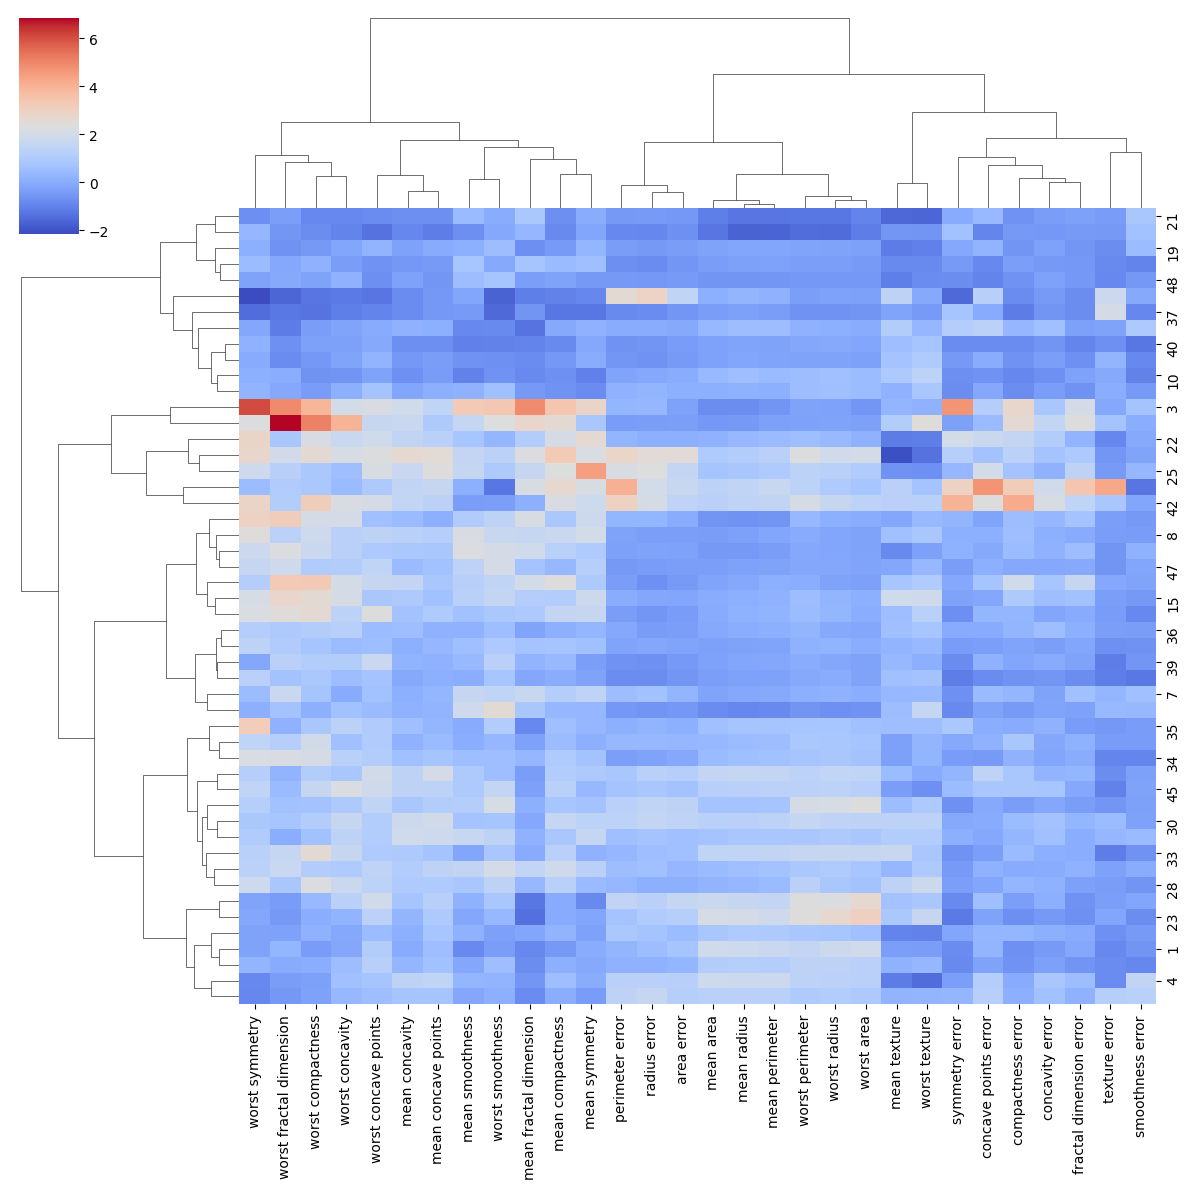

In [9]:
# Visualizing the first 50 samples for better readability
plt.figure(figsize=(10, 8))
sns.clustermap(df_scaled.iloc[:50, :], 
               cmap='coolwarm', 
               metric='euclidean', 
               method='ward',
               figsize=(12, 12))

plt.show()


c:\miniconda3\envs\assignment_1\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\miniconda3\envs\assignment_1\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


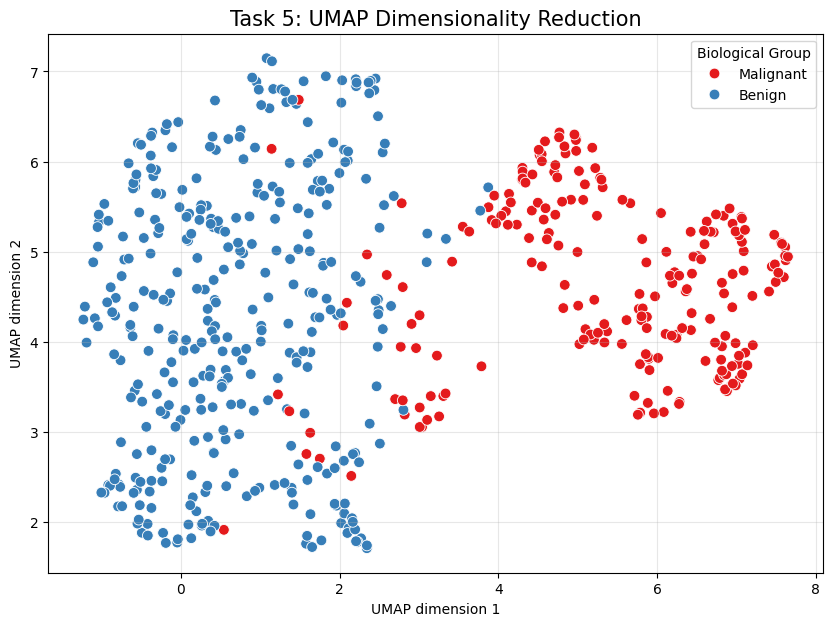

In [11]:
import umap

# 1. Initialize and run UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(df_scaled)

# 2. Create a DataFrame for the UMAP results
df_umap = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
df_umap['Group'] = labels.values

# 3. Create the 2D Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_umap, x='UMAP1', y='UMAP2', hue='Group', palette='Set1', s=60)

plt.title('Task 5: UMAP Dimensionality Reduction', fontsize=15)
plt.xlabel('UMAP dimension 1')
plt.ylabel('UMAP dimension 2')
plt.legend(title='Biological Group')
plt.grid(True, alpha=0.3)
plt.show()
